In [1]:
#%%
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
period='rcp85'
variable='t'
domain = 'd03'
if variable == "t":
    var = 'T2'
    filename = 't_'+domain+'_daily_newdim'
elif variable == "pr":
    var = 'pr'
    filename = 'pr_'+domain+'_daily'
elif variable == "wind":
    var = 'wspd'
    if domain=="d03":
        filename =  'wind_d03_daily_wspd'#'wspd_'+domain+'_mon'
    else:
        filename = "wind_"+domain+'_daily'
    
geo_em_file = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/domain/geo_em.'+domain+'.nc'  #'/Users/evagnegy/Desktop/CanESM2_WRF_Eval/domain/geo_em.'+domain+'.nc'
basepath='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/'
#gridded_data_path = '/Users/evagnegy/Desktop/CanESM2_WRF_Eval/gridded_model_data/daily/'
gridded_data_path = basepath+'historical/variables_complete/'
future_data_path = basepath+period+'/variables_complete/'

# === Paths and filenames ===
hist_path = gridded_data_path + filename + '.nc'
fut_path = future_data_path + filename + '.nc'

#fut_path = future_data_path + filename + f'_{period}.nc'
out_path = f"{filename}_{period}_monthly_deltas.nc"

# === Load land mask ===
landmask = xr.open_dataset(geo_em_file)['LANDMASK'].squeeze()
landmask = landmask.rename({'south_north': 'lat', 'west_east': 'lon'})  # ensure standard naming
if 'south_north' in landmask.coords:
    landmask = landmask.rename({'south_north': 'lat'})
if 'west_east' in landmask.coords:
    landmask = landmask.rename({'west_east': 'lon'})
print(landmask.dims)
# landmask= landmask.rename({'lon':'longitude' , 'lat:'latitude'})
print(np.shape(landmask))
# === Load data ===
var_hist = xr.open_dataset(hist_path)[var]
var_fut = xr.open_dataset(fut_path)[var]
# === Ensure lat/lon are consistent ===
#var_hist = var_hist.rename({'south_north': 'lat', 'west_east': 'lon'})
#var_fut = var_fut.rename({'south_north': 'lat', 'west_east': 'lon'})

# === Group by month and take mean ===
hist_monthly = var_hist.groupby('time.month').mean('time')
fut_monthly = var_fut.groupby('time.month').mean('time')

# === Compute fractional change (future - historical) / historical ===
delta = (fut_monthly - hist_monthly)  # shape: (month, lat, lon)

if variable=='t':
    delta = (delta ) 
    delta=delta.rename({'longitude': 'lon', 'latitude': 'lat'})
    if 'longitude' in delta.coords:
        delta = delta.rename({'longitude': 'lon'})
    if 'latitude' in delta.coords:
        delta = delta.rename({'latitude': 'lat'})
else:
    delta = (delta / (hist_monthly)) * 100

print('dimensions', delta.dims)
    # Binary masks

print(landmask)
# Apply masks to data
landmask = landmask.values #.transpose('lon', 'lat')  # Now shape matches delta
land_mask = (landmask == 1)
ocean_mask = (landmask == 0)

# Step 3: Create raw index-based mask
#
#print("delta dims:", delta.dims)
#print("landmask dims:", land_mask.dims)

print('here')
# === Area weights ===
weights = np.cos(np.deg2rad(var_hist['lat'].values))
#weights=weights.rename({'longitude': 'lon', 'latitude': 'lat'})
#if 'longitude' in delta.coords:
#    weights = weights.rename({'longitude': 'lon'})
#if 'latitude' in delta.coords:
#    weights = weights.rename({'latitude': 'lat'})
#print(weights)
#weights = weights
#weights = weights.broadcast_like(delta)
# Apply mask to weights with multiplication (avoids NaNs)
#print(weights.dims)
land_weights = weights * land_mask
ocean_weights = weights* ocean_mask
print('here...starting loop')
# Safe weighted averages
# land_mean = hist_mo_l.weighted(land_weights).mean(dim=['lat', 'lon'])
#ocean_mean = hist_mo_oc.weighted(ocean_weights).mean(dim=['lat', 'lon'])
#land_fut = fut_mo_l.weighted(land_weights).mean(dim=['lat', 'lon'])
#ocean_fut = fut_mo_oc.weighted(ocean_weights).mean(dim=['lat', 'lon'])
land_del =np.zeros(12)
ocean_del=np.zeros(12)
#print(land_mask.dims, delta.dims)
#print(land_mask, delta)
for kk in np.arange(12):
    X=delta[kk,:,:]
    del_mo_l = X.where(land_mask)
    del_mo_oc = X.where(ocean_mask)
    land_del[kk] = del_mo_l.mean(dim=['lon', 'lat'])
    ocean_del[kk] = del_mo_oc.mean(dim=['lon', 'lat'])
print('here')
print("June land change:", land_del[7])
print("June ocean change:", ocean_del[7])




('lat', 'lon')
(300, 300)
dimensions ('month', 'lon', 'lat')
<xarray.DataArray 'LANDMASK' (lat: 300, lon: 300)> Size: 360kB
[90000 values with dtype=float32]
Dimensions without coordinates: lat, lon
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    units:        none
    description:  Landmask : 1=land, 0=water
    stagger:      M
    sr_x:         1
    sr_y:         1
here
here...starting loop
here
June land change: 3.513378904694845
June ocean change: 2.4520563742372814


In [2]:
land_H =np.zeros(12)
ocean_H=np.zeros(12)
land_F =np.zeros(12)
ocean_F=np.zeros(12)
#print(land_mask.dims, delta.dims)
#print(land_mask, delta)
for kk in np.arange(12):
    H=hist_monthly[kk,:,:]
    F=fut_monthly[kk,:,:]
    H_mo_l = H.where(land_mask)
    H_mo_oc = H.where(ocean_mask)
    F_mo_l = F.where(land_mask)
    F_mo_oc = F.where(ocean_mask)

    land_H[kk] = H_mo_l.mean(dim=['longitude', 'latitude'])
    ocean_H[kk] = H_mo_oc.mean(dim=['longitude', 'latitude'])
    land_F[kk] = F_mo_l.mean(dim=['longitude', 'latitude'])
    ocean_F[kk] = F_mo_oc.mean(dim=['longitude', 'latitude'])

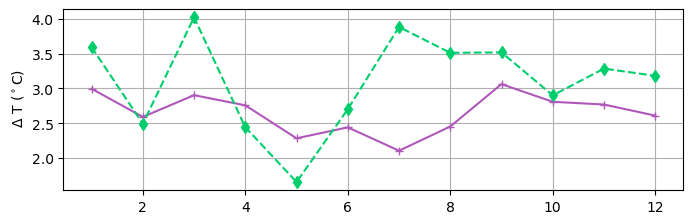

In [3]:
color1='#00CD6C'#green
color2='#AF58BA'#purple
color3='#FFC61E' #yello
color4='#009ADE' #blue
color5='#F28522' #orange
color6='#A0B1BA' #gray
color7='#A6761D'#brown
color8='#FF1F5B' #red
months = np.arange(1, 13)
plt.figure(figsize=(8,8))
ax = plt.subplot(3, 1, 1)
#om, lm=getaverages('t', period, domain)


plt.plot(months, ocean_del, label='Ocean', marker='+', color=color2)
plt.plot(months, land_del, label='Land', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)

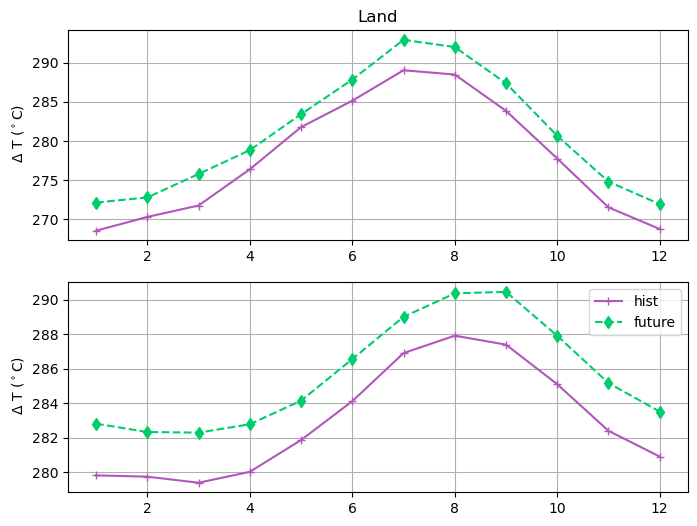

In [4]:
color1='#00CD6C'#green
color2='#AF58BA'#purple
color3='#FFC61E' #yello
color4='#009ADE' #blue
color5='#F28522' #orange
color6='#A0B1BA' #gray
color7='#A6761D'#brown
color8='#FF1F5B' #red
months = np.arange(1, 13)
plt.figure(figsize=(8,6))
ax = plt.subplot(2, 1, 1)
#om, lm=getaverages('t', period, domain)


plt.plot(months, land_H, label='hist', marker='+', color=color2)
plt.plot(months, land_F, label='future', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)
plt.title('Land')

ax = plt.subplot(2, 1, 2)
#om, lm=getaverages('t', period, domain)


plt.plot(months, ocean_H, label='hist', marker='+', color=color2)
plt.plot(months, ocean_F, label='future', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)
plt.legend()

def getaverages(variable, period, domain):
    if variable == "t":
        var = 'T2'
        filename = 't_'+domain+'_daily_newdim'
    elif variable == "pr":
        var = 'pr'
        filename = 'pr_'+domain+'_daily'
    elif variable == "wind":
        var = 'wspd'
        if domain=="d03":
            filename =  'wind_d03_daily_wspd'#'wspd_'+domain+'_mon'
        else:
            filename = "wind_"+domain+'_daily'
        
    geo_em_file = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/domain/geo_em.'+domain+'.nc'  #'/Users/evagnegy/Desktop/CanESM2_WRF_Eval/domain/geo_em.'+domain+'.nc'
    basepath='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/'
    #gridded_data_path = '/Users/evagnegy/Desktop/CanESM2_WRF_Eval/gridded_model_data/daily/'
    gridded_data_path = basepath+'historical/variables_complete/'
    future_data_path = basepath+period+'/variables_complete/'
    
    # === Paths and filenames ===
    hist_path = gridded_data_path + filename + '.nc'
    fut_path = future_data_path + filename + '.nc'
    
    #fut_path = future_data_path + filename + f'_{period}.nc'
    out_path = f"{filename}_{period}_monthly_deltas.nc"
    
    # === Load land mask ===
    landmask = xr.open_dataset(geo_em_file)['LANDMASK'].squeeze()
    landmask = landmask.rename({'south_north': 'lat', 'west_east': 'lon'})  # ensure standard naming
    if 'south_north' in landmask.coords:
        landmask = landmask.rename({'south_north': 'lat'})
    if 'west_east' in landmask.coords:
        landmask = landmask.rename({'west_east': 'lon'})
    print(landmask.dims)
    # landmask= landmask.rename({'lon':'longitude' , 'lat:'latitude'})
    print(np.shape(landmask))
    # === Load data ===
    var_hist = xr.open_dataset(hist_path)[var]
    var_fut = xr.open_dataset(fut_path)[var]
    # === Ensure lat/lon are consistent ===
    #var_hist = var_hist.rename({'south_north': 'lat', 'west_east': 'lon'})
    #var_fut = var_fut.rename({'south_north': 'lat', 'west_east': 'lon'})
    
    # === Group by month and take mean ===
    hist_monthly = var_hist.groupby('time.month').mean('time')
    fut_monthly = var_fut.groupby('time.month').mean('time')
    
    # === Compute fractional change (future - historical) / historical ===
    delta = (fut_monthly - hist_monthly)  # shape: (month, lat, lon)
    
    if variable=='t':
        delta = (delta ) 
        delta=delta.rename({'longitude': 'lon', 'latitude': 'lat'})
        if 'longitude' in delta.coords:
            delta = delta.rename({'longitude': 'lon'})
        if 'latitude' in delta.coords:
            delta = delta.rename({'latitude': 'lat'})
    else:
        delta = (delta / (hist_monthly)) * 100
    
        # Binary masks
    
    print(landmask)
    # Apply masks to data
    landmask = landmask.values #.transpose('lon', 'lat')  # Now shape matches delta
    land_mask = (landmask == 1)
    ocean_mask = (landmask == 0)
    
    # Step 3: Create raw index-based mask
    #
    #print("delta dims:", delta.dims)
    #print("landmask dims:", land_mask.dims)
    
    # === Area weights ===
    weights = np.cos(np.deg2rad(var_hist['lat'].values))
    #weights=weights.rename({'longitude': 'lon', 'latitude': 'lat'})
    #if 'longitude' in delta.coords:
    #    weights = weights.rename({'longitude': 'lon'})
    #if 'latitude' in delta.coords:
    #    weights = weights.rename({'latitude': 'lat'})
    #print(weights)
    #weights = weights
    #weights = weights.broadcast_like(delta)
    # Apply mask to weights with multiplication (avoids NaNs)
    #print(weights.dims)
    land_weights = weights * land_mask
    ocean_weights = weights* ocean_mask
    # Safe weighted averages
    # land_mean = hist_mo_l.weighted(land_weights).mean(dim=['lat', 'lon'])
    #ocean_mean = hist_mo_oc.weighted(ocean_weights).mean(dim=['lat', 'lon'])
    #land_fut = fut_mo_l.weighted(land_weights).mean(dim=['lat', 'lon'])
    #ocean_fut = fut_mo_oc.weighted(ocean_weights).mean(dim=['lat', 'lon'])
    land_del =np.zeros(12)
    ocean_del=np.zeros(12)
    #print(land_mask.dims, delta.dims)
    #print(land_mask, delta)
    for kk in np.arange(12):
        X=delta[kk,:,:]
        del_mo_l = X.where(land_mask)
        del_mo_oc = X.where(ocean_mask)
        land_del[kk] = del_mo_l.mean(dim=['lon', 'lat'])
        ocean_del[kk] = del_mo_oc.mean(dim=['lon', 'lat'])
    print("June land change:", land_del[7])
    print("June ocean change:", ocean_del[7])
    return ocean_del, land_del
    


In [11]:
def getaverages(variable, period, domain):
    if variable == "t":
        var = 'T2'
        filename = 't_'+domain+'_daily_newdim'
    elif variable == "pr":
        var = 'pr'
        filename = 'pr_'+domain+'_daily'
    elif variable == "wind":
        var = 'wspd'
        if domain=="d03":
            filename = 'wind_d03_daily_wspd'
        else:
            filename = "wind_"+domain+'_daily'
        
    geo_em_file = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/domain/geo_em.'+domain+'.nc'
    basepath='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/'
    gridded_data_path = basepath+'historical/variables_complete/'
    future_data_path = basepath+period+'/variables_complete/'
    
    hist_path = gridded_data_path + filename + '.nc'
    fut_path  = future_data_path  + filename + '.nc'

    # === Load land mask ===
    landmask = xr.open_dataset(geo_em_file)['LANDMASK'].squeeze()
    landmask = landmask.rename({'south_north': 'lat', 'west_east': 'lon'})
    landmask = landmask.values
    land_mask  = (landmask == 1)
    ocean_mask = (landmask == 0)

    # === Load data ===
    var_hist = xr.open_dataset(hist_path)[var]
    var_fut  = xr.open_dataset(fut_path)[var]

    # === Climatological monthly means (for delta) ===
    hist_monthly = var_hist.groupby('time.month').mean('time')
    fut_monthly  = var_fut.groupby('time.month').mean('time')

    delta = fut_monthly - hist_monthly

    if variable == 't':
        delta = delta.rename({'longitude': 'lon', 'latitude': 'lat'})
    else:
        delta = (delta / hist_monthly) * 100

    # === Per-year monthly means (for SEM) ===
    hist_ym = var_hist.resample(time='1MS').mean()
    fut_ym  = var_fut.resample(time='1MS').mean()

    # === Area weights (2D numpy) ===
    weights      = np.cos(np.deg2rad(var_hist['lat'].values))  # shape: (nlat, nlon)
    land_weights  = weights * land_mask
    ocean_weights = weights * ocean_mask

    land_del  = np.zeros(12)
    ocean_del = np.zeros(12)
    land_sem  = np.zeros(12)
    ocean_sem = np.zeros(12)

    for kk in range(12):
        month_num = kk + 1

        # --- Climatological delta (same as working version) ---
        X = delta[kk, :, :]
        del_mo_l  = X.where(land_mask)
        del_mo_oc = X.where(ocean_mask)
        land_del[kk]  = float(del_mo_l.mean(dim=['lon', 'lat']))
        ocean_del[kk] = float(del_mo_oc.mean(dim=['lon', 'lat']))

        # --- Interannual time series using numpy to avoid dim name issues ---
        # shape: (n_years, nlat, nlon)
        hist_m = hist_ym.sel(time=hist_ym.time.dt.month == month_num).values
        fut_m  = fut_ym.sel(time=fut_ym.time.dt.month  == month_num).values

        # Weighted spatial mean for each year → shape: (n_years,)
        def wmean_timeseries(data_3d, wts_2d):
            """data_3d: (nyears, nlat, nlon), wts_2d: (nlat, nlon)"""
            w = wts_2d[np.newaxis, :, :]           # broadcast over time
            return np.nansum(data_3d * w, axis=(1,2)) / np.nansum(w * np.isfinite(data_3d), axis=(1,2))

        hist_ts_l = wmean_timeseries(hist_m, land_weights)
        fut_ts_l  = wmean_timeseries(fut_m,  land_weights)
        hist_ts_o = wmean_timeseries(hist_m, ocean_weights)
        fut_ts_o  = wmean_timeseries(fut_m,  ocean_weights)

        if variable != 't':
            # Scale SEM to % same as delta
            hist_mean_l = np.nanmean(hist_ts_l)
            hist_mean_o = np.nanmean(hist_ts_o)
            hist_ts_l = (hist_ts_l / abs(hist_mean_l)) * 100
            fut_ts_l  = (fut_ts_l  / abs(hist_mean_l)) * 100
            hist_ts_o = (hist_ts_o / abs(hist_mean_o)) * 100
            fut_ts_o  = (fut_ts_o  / abs(hist_mean_o)) * 100

        # Propagated SEM on the delta
        land_sem[kk]  = np.sqrt((np.std(hist_ts_l, ddof=1)/np.sqrt(len(hist_ts_l)))**2 +
                                (np.std(fut_ts_l,  ddof=1)/np.sqrt(len(fut_ts_l)))**2)
        ocean_sem[kk] = np.sqrt((np.std(hist_ts_o, ddof=1)/np.sqrt(len(hist_ts_o)))**2 +
                                (np.std(fut_ts_o,  ddof=1)/np.sqrt(len(fut_ts_o)))**2)

    print("June land change:",  land_del[5], "±", land_sem[5])
    print("June ocean change:", ocean_del[5], "±", ocean_sem[5])

    return ocean_del, ocean_sem, land_del, land_sem

In [12]:
#%%

period='rcp85'
variable='t'
domain = 'd03'
do_85, o_sems, dl_85, l_sems = getaverages(variable, period, domain)
#do_85,dl_85=getaverages(variable, period, domain)

June land change: 2.7013785478206764 ± 0.4462092769881082
June ocean change: 2.4398553941290486 ± 0.04988112591909064


In [13]:
period='rcp85'
variable='t'
do_85,o_se85,dl_85, dl_se85=getaverages(variable, period, domain)
variable='wind'
do_w_85,do_w_se85,dl_w_85, dl_w_se85=getaverages(variable, period, domain)
variable='pr'
do_pr_85,do_pr_se85,dl_pr_85, dl_pr_se85=getaverages(variable, period, domain)

June land change: 2.7013785478206764 ± 0.4462092769881082
June ocean change: 2.4398553941290486 ± 0.04988112591909064
June land change: -3.977526993732607 ± 1.4433128249414304
June ocean change: -1.3489426840852345 ± 3.610828212149809


/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unab

June land change: -8.318004474470158 ± 13.281506231191411
June ocean change: -3.6103998580006014 ± 11.524231941631916


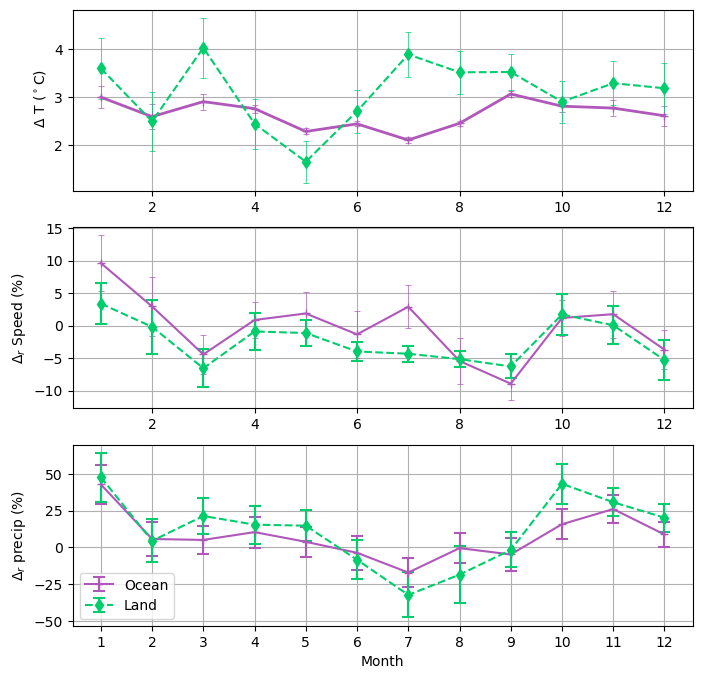

In [39]:
color1='#00CD6C'#green
color2='#AF58BA'#purple
color3='#FFC61E' #yello
color4='#009ADE' #blue
color5='#F28522' #orange
color6='#A0B1BA' #gray
color7='#A6761D'#brown
color8='#FF1F5B' #red
months = np.arange(1, 13)
plt.figure(figsize=(8,8))
ax = plt.subplot(3, 1, 1)
#om, lm=getaverages('t', period, domain)
caps=2.5
capw=0.5
capt=0.5
plt.errorbar(months, do_85, yerr=o_se85,
             label='Ocean', marker='+', color=color2, linewidth=2,
             capsize=caps, capthick=capt, elinewidth=capw)

plt.errorbar(months, dl_85, yerr=dl_se85,
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=caps, capthick=capt, elinewidth=capw)
#plt.plot(months, do_85, label='Ocean', marker='+', color=color2)
#plt.plot(months, dl_85, label='Land', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)

ax = plt.subplot(3, 1, 2)
#om, lm=getaverages('t', period, domain)
plt.errorbar(months, do_w_85, yerr=do_w_se85,
             label='Ocean', marker='+', color=color2,
             capsize=caps, capthick=capt, elinewidth=capw)

plt.errorbar(months, dl_w_85, yerr=dl_w_se85,
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=4, capthick=1.5, elinewidth=1.5)
#plt.plot(months, do_w_85, label='Ocean', marker='+', color=color2)
#plt.plot(months, dl_w_85, label='Land', linestyle='--', marker='d', color=color1, markeredgecolor=color1)

plt.grid(True)
plt.ylabel(r'$\Delta_r$ Speed (%)')

#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
ax = plt.subplot(3, 1, 3)
#om, lm=getaverages('t', period, domain)
plt.errorbar(months, do_pr_85, yerr=do_pr_se85,
             label='Ocean', marker='+', color=color2,
             capsize=4, capthick=1.5, elinewidth=1.5)

plt.errorbar(months, dl_pr_85, yerr=dl_pr_se85,
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=4, capthick=1.5, elinewidth=1.5)
plt.ylabel(r'$\Delta_r$ precip (%)')

plt.xlabel('Month')
#plt.ylabel(f'Mean fractional change in {var}')
#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
plt.xticks(months)
plt.grid(True)
plt.legend()

In [32]:
period='rcp45'
variable='t'
do,do_se, dl, dl_se=getaverages(variable, period, domain)
variable='wind'
do_w,do_w_se,dl_w,dl_w_se=getaverages(variable, period, domain)
variable='pr'
do_pr,do_pr_se,dl_pr, dl_pr_se=getaverages(variable, period, domain)

June land change: 3.229921605395465 ± 0.5303065708706449
June ocean change: 1.8387834121112547 ± 0.053404984801308036
June land change: -3.5089853359377026 ± 1.570342953499565
June ocean change: 1.469764320811502 ± 3.4055547292801283


/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unab

June land change: -12.485512389332333 ± 13.883932336565598
June ocean change: -3.2506427206179356 ± 11.874139785905033


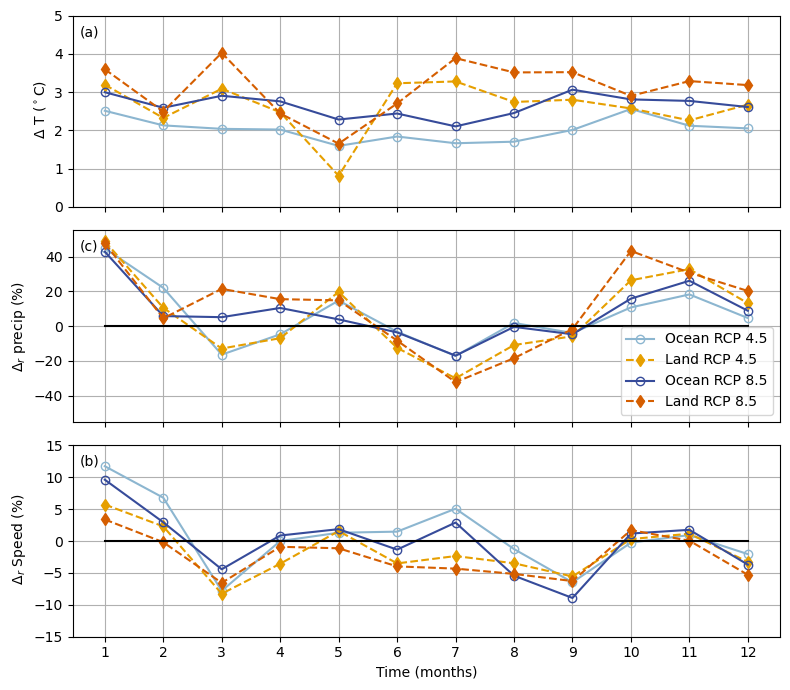

In [21]:
# Ocean colors
color3 = '#364B9A'  # Ocean (historical) — deep blue
color2 = '#8CB6D0'  # Ocean (RCP8.5) — light muted blue

# Land colors
color4 = '#D55E00'  # Land (historical) — warm reddish-orange
color1 = '#E69F00'  # Land (RCP8.5) — golden yellow

subpanel = ['(a)','(b)','(c)','(d)', '(e)', '(f)', 'g','h','i','j']
#subpanel = ['1','2','3', '4', '5','6']

at=0.01
bt=.95

months = np.arange(1, 13)
plt.figure(figsize=(8,7))
ax = plt.subplot(3, 1, 1)
#om, lm=getaverages('t', period, domain)

plt.plot(months, do, label='ocean', marker='o', color=color2, markerfacecolor='none')
plt.plot(months, dl, label='land', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)

plt.plot(months, do_85, label='ocean', marker='o', color=color3, markerfacecolor='none')
plt.plot(months, dl_85, label='land RCP 8.5', linestyle='--', marker='d', color=color4,  markeredgecolor=color4)
ax.text(at, bt, subpanel[0], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)
plt.xticks(months)
plt.axis('tight')
plt.ylim([0,5])
ax.set_xticklabels([])
ax = plt.subplot(3, 1, 3)
#om, lm=getaverages('t', period, domain)

plt.plot(months, do_w, label='Ocean', marker='o', color=color2, markerfacecolor='none')
plt.plot(months, dl_w, label='Land', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)

plt.plot(months, do_w_85, label='Ocean RCP8.5', marker='o', color=color3, markerfacecolor='none')
plt.plot(months, dl_w_85, label='Land RCP 8.5', linestyle='--', marker='d', color=color4,  markeredgecolor=color4)
plt.plot(months, np.zeros(12), '-k')
ax.text(at, bt, subpanel[1], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
plt.ylim([-15,15])
plt.grid(True)
plt.xticks(months)
plt.ylabel(r' $\Delta_r$ Speed (%)')
plt.xlabel('Time (months)')
#plt.axis('tight')
#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
ax = plt.subplot(3, 1, 2)
#om, lm=getaverages('t', period, domain)

plt.plot(months, do_pr, label='Ocean RCP 4.5', marker='o', color=color2, markerfacecolor='none')
plt.plot(months, dl_pr, label='Land RCP 4.5', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)

plt.plot(months, do_pr_85, label='Ocean RCP 8.5', marker='o', color=color3, markerfacecolor='none')
plt.plot(months, dl_pr_85, label='Land RCP 8.5', linestyle='--', marker='d', color=color4,  markeredgecolor=color4)
plt.plot(months, np.zeros(12), '-k')

plt.ylabel(r'$\Delta_r$ precip (%)')
ax.set_xticklabels([])

#plt.ylabel(f'Mean fractional change in {var}')
#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
plt.xticks(months)
ax.text(at, bt, subpanel[2], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
plt.ylim([-55,55])
plt.grid(True)
plt.legend()
#plt.axis('tight')
plt.tight_layout()
plt.savefig('Regional_averages_relative.png', format='png', bbox_inches='tight',transparent=False,dpi=500)


In [22]:
print('annual average warming over land', np.mean(dl), 'water', np.mean(do), ' difference ', np.mean(do-dl))
print('annual average warming over land', np.mean(dl_85), 'water', np.mean(do_85), ' difference ', np.mean(do_85-dl_85))
print('difference in scenarios', np.mean(do_85-do), np.mean(dl_85-dl), np.mean([do_85,dl_85]) - np.mean([do,dl]))

annual average warming over land 2.6201995443174173 water 2.0199936334489093  difference  -0.6002059108685078
annual average warming over land 3.099617361211825 water 2.6477480779165363  difference  -0.4518692832952895
difference in scenarios 0.6277544444676271 0.47941781689440877 0.5535861306810181


In [23]:
#%%
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os


def getdayofyear(period, variable, domain):
    if variable == "t":
        var = 'T2'
        filename = 't_'+domain+'_daily_newdim'
    elif variable == "pr":
        var = 'pr'
        filename = 'pr_'+domain+'_daily'
    elif variable == "wind":
        var = 'wspd'
        if domain=="d03":
            filename =  'wind_d03_daily_wspd'#'wspd_'+domain+'_mon'
        else:
            filename = "wind_"+domain+'_daily'
        
    geo_em_file = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/domain/geo_em.'+domain+'.nc'  
    basepath='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/'

    if period=='hist':
        data_path = basepath+'historical/variables_complete/'
    else:
        data_path = basepath+period+'/variables_complete/'
    
    # === Paths and filenames ===
    path0 = data_path + filename + '.nc'
    
    # === Load land mask ===
    landmask = xr.open_dataset(geo_em_file)['LANDMASK'].squeeze()
    landmask = landmask.rename({'south_north': 'lat', 'west_east': 'lon'})  # ensure standard naming
    if 'south_north' in landmask.coords:
        landmask = landmask.rename({'south_north': 'lat'})
    if 'west_east' in landmask.coords:
        landmask = landmask.rename({'west_east': 'lon'})
    
    var0 = xr.open_dataset(path0)[var]

    # === Group by month and take mean ===
    var0 = var0.groupby('time.dayofyear').mean('time')
    
    
    if variable=='t':
        var0=var0.rename({'longitude': 'lon', 'latitude': 'lat'})

    # Apply masks to data
    landmask = landmask.values #.transpose('lon', 'lat')  # Now shape matches delta
    land_mask = (landmask == 1)
    ocean_mask = (landmask == 0)
    
    # Step 3: Create raw index-based mask
    #
    #print("delta dims:", delta.dims)
    # === Area weights ===
    weights = np.cos(np.deg2rad(var0['lat'].values))
    land_weights = weights * land_mask
    ocean_weights = weights* ocean_mask
    print('here...starting loop')
    lt=len(var0)
    land_del =np.zeros(lt)
    ocean_del=np.zeros(lt)
    for kk in np.arange(lt):
        X=var0[kk,:,:]
        del_mo_l = X.where(land_mask)
        del_mo_oc = X.where(ocean_mask)
        land_del[kk] = del_mo_l.mean(dim=['lon', 'lat'])
        ocean_del[kk] = del_mo_oc.mean(dim=['lon', 'lat'])

    # same for others
    #monthly = var0.groupby('time.month').mean('time')

    return land_del, ocean_del#, monthly



In [24]:
period='rcp85'
variable='t'
domain = 'd03'
land_85, ocean_85=getdayofyear(period, variable, domain)
land_45, ocean_45=getdayofyear('rcp45', variable, domain)
land_hist, ocean_hist=getdayofyear('hist', variable, domain)

here...starting loop
here...starting loop
here...starting loop


In [25]:
# Peak and trough DOY for land (already defined)
peaks_l = np.array([np.argmax(land_hist), np.argmax(land_45), np.argmax(land_85)])
troughs_l = np.array([np.argmin(land_hist), np.argmin(land_45), np.argmin(land_85)])
amplitude_l=[land_hist.max()-land_hist.min(), land_45.max()-land_45.min(), land_85.max()-land_85.min()]
# Peak and trough DOY for ocean (already defined)
peaks_o = np.array([np.argmax(ocean_hist), np.argmax(ocean_45), np.argmax(ocean_85)])
troughs_o = np.array([np.argmin(ocean_hist), np.argmin(ocean_45), np.argmin(ocean_85)])
amplitude=[ocean_hist.max()-ocean_hist.min(), ocean_45.max()-ocean_45.min(), ocean_85.max()-ocean_85.min()]

In [26]:
def getpeaks( variable, domain):
    land_85, ocean_85=getdayofyear('rcp85', variable, domain)
    land_45, ocean_45=getdayofyear('rcp45', variable, domain)
    land_hist, ocean_hist=getdayofyear('hist', variable, domain)
    peaks_l = np.array([np.argmax(land_hist), np.argmax(land_45), np.argmax(land_85)])
    troughs_l = np.array([np.argmin(land_hist), np.argmin(land_45), np.argmin(land_85)])
    amplitude_l=[land_hist.max()-land_hist.min(), land_45.max()-land_45.min(), land_85.max()-land_85.min()]
    # Peak and trough DOY for ocean (already defined)
    peaks_o = np.array([np.argmax(ocean_hist), np.argmax(ocean_45), np.argmax(ocean_85)])
    troughs_o = np.array([np.argmin(ocean_hist), np.argmin(ocean_45), np.argmin(ocean_85)])
    amplitude_o=[ocean_hist.max()-ocean_hist.min(), ocean_45.max()-ocean_45.min(), ocean_85.max()-ocean_85.min()]
    return peaks_l, troughs_l, amplitude_l, peaks_o, troughs_o, amplitude_o

In [27]:
peaks_l_pr, troughs_l_pr, amplitude_l_pr, peaks_o_pr, troughs_o_pr, amplitude_o_pr=getpeaks('pr', domain)

/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


here...starting loop


/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


here...starting loop


/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


here...starting loop


In [28]:
#troughs_o_pr=land_o_pr

In [29]:
peaks_l_ws, troughs_l_ws, amplitude_l_ws, peaks_o_ws, troughs_o_ws, amplitude_o_ws=getpeaks('wind', domain)

here...starting loop
here...starting loop
here...starting loop


troughs_o_ws=land_o_ws

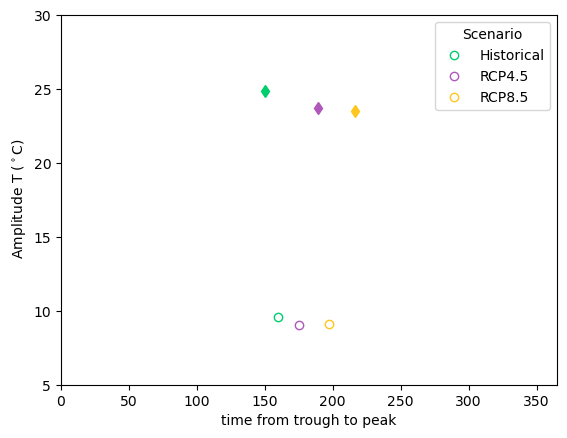

In [30]:
import matplotlib.pyplot as plt

# Example data
color1='#00CD6C'#green
color2='#AF58BA'#purple
color3='#FFC61E' #yello
color4='#009ADE' #blue
color5='#F28522' #orange
color6='#A0B1BA' #gray
color7='#A6761D'#brown
color8='#FF1F5B' #red
colors = [color1, color2, color3]
labels = ['Historical', 'RCP4.5', 'RCP8.5']

# Plot ocean points with individual colors
for i, (x, y) in enumerate(zip(abs(peaks_o - troughs_o), amplitude)):
    plt.plot(x, y, 'o', markerfacecolor='none', color=colors[i % len(colors)],label=labels[i])

# Plot land points with individual colors
for i, (x, y) in enumerate(zip(abs(peaks_l - troughs_l), amplitude_l)):
    plt.plot(x, y, 'd', color=colors[i % len(colors)])

plt.ylim([5, 30])
plt.xlim([0, 365])
plt.ylabel(r' Amplitude T ($^\circ \mathrm{C}$)')
plt.xlabel('time from trough to peak')
plt.legend(title='Scenario')

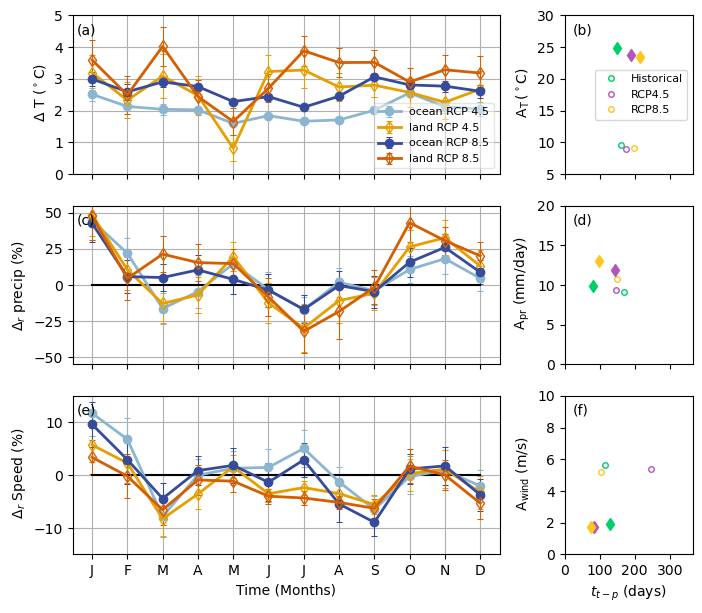

In [45]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Ocean colors
color3 = '#364B9A'  # Ocean (historical) — deep blue
color2 = '#8CB6D0'  # Ocean (RCP8.5) — light muted blue

# Land colors
color4 = '#D55E00'  # Land (historical) — warm reddish-orange
color1 = '#E69F00'  # Land (RCP8.5) — golden yellow

plt.figure(figsize=(8,7))
ax = plt.subplot(3, 1, 1)
#om, lm=getaverages('t', period, domain)
def plot_error(do,do_se,dl, dl_se, do_85,do_se85, dl_85, dl_se85): 
    caps=2.5
    capw=0.75
    capt=0.75
    lw=2
    plt.errorbar(months, do, yerr=do_se,
                 label='ocean RCP 4.5', marker='o', color=color2, linewidth=lw, 
                 capsize=caps, capthick=capt, elinewidth=capw)
    
    plt.errorbar(months, dl, yerr=dl_se,
                 label='land RCP 4.5', linestyle='-', marker='d', color=color1,markerfacecolor='None',
                 markeredgecolor=color1,linewidth=lw, 
                 capsize=caps, capthick=capt, elinewidth=capw)
    
    plt.errorbar(months, do_85, yerr=do_se85,
                 label='ocean RCP 8.5', marker='o', color=color3,linewidth=lw, 
                 capsize=caps, capthick=capt, elinewidth=capw)
    
    plt.errorbar(months, dl_85, yerr=dl_se85,
                 label='land RCP 8.5', linestyle='-', marker='d', color=color4,markerfacecolor='None',
                 markeredgecolor=color4,linewidth=lw, 
                 capsize=caps, capthick=capt, elinewidth=capw)
plot_error(do,do_se,dl, dl_se, do_85,o_se85, dl_85, dl_se85)
#plt.plot(months, do, label='ocean RCP 4.5', marker='o', color=color2, markerfacecolor='none')
#plt.plot(months, dl, label='land RCP 4.5', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)

#plt.plot(months, do_85, label='ocean RCP 4.5', marker='o', color=color3, markerfacecolor='none')
#plt.plot(months, dl_85, label='land RCP 8.5', linestyle='--', marker='d', color=color4,  markeredgecolor=color4)
ax.text(at, bt, subpanel[0], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)
plt.xticks(months)
plt.axis('tight')
plt.legend( fontsize=8, framealpha=0.5)
plt.ylim([0,5])
ax.set_xticklabels([])

# Use divider to append bar plot to the right
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='30%', pad=0.65)
cax.text(at+0.05, bt, subpanel[1], transform=cax.transAxes,  va='top', fontweight='normal',zorder=1000)

# Plot ocean points with individual colors
for i, (x, y) in enumerate(zip(abs(peaks_o - troughs_o), amplitude)):
    plt.plot(x, y, 'o', markerfacecolor='none', color=colors[i % len(colors)],label=labels[i], markersize=4)

# Plot land points with individual colors
for i, (x, y) in enumerate(zip(abs(peaks_l - troughs_l), amplitude_l)):
    plt.plot(x, y, 'd', color=colors[i % len(colors)])

plt.ylim([5, 30])
plt.xlim([0, 365])
plt.ylabel(r' A$_{\mathrm{T}} \, (^\circ \mathrm{C}$)')
plt.legend( fontsize=8)
cax.set_xticks([0,100,200,300])
cax.set_xticklabels([])
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
ax = plt.subplot(3, 1, 2)
#om, lm=getaverages('t', period, domain)
plot_error(do_pr,do_pr_se,dl_pr, dl_pr_se, do_pr_85,do_pr_se85, dl_pr_85, dl_pr_se85)
#plt.plot(months, do_pr, label='Ocean RCP 4.5', marker='o', color=color2, markerfacecolor='none')
#plt.plot(months, dl_pr, label='Land RCP 4.5', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)

#plt.plot(months, do_pr_85, label='Ocean RCP 8.5', marker='o', color=color3, markerfacecolor='none')
#plt.plot(months, dl_pr_85, label='Land RCP 8.5', linestyle='--', marker='d', color=color4,  markeredgecolor=color4)
plt.plot(months, np.zeros(12), '-k')

plt.ylabel(r'$\Delta_r$ precip (%)')
ax.set_xticklabels([])

#plt.ylabel(f'Mean fractional change in {var}')
#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
plt.xticks(months)
ax.text(at, bt, subpanel[2], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
plt.ylim([-55,55])
plt.grid(True)
#plt.axis('tight')
# Use divider to append bar plot to the right


divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='30%', pad=0.65)

# Plot ocean points with individual colors
for i, (x, y) in enumerate(zip(abs(peaks_o_pr - troughs_o_pr), amplitude_o_pr)):
    plt.plot(x, y, 'o', markerfacecolor='none', color=colors[i % len(colors)],label=labels[i], markersize=4)

# Plot land points with individual colors
for i, (x, y) in enumerate(zip(abs(peaks_l_pr - troughs_l_pr), amplitude_l_pr)):
    plt.plot(x, y, 'd', color=colors[i % len(colors)])
cax.text(at+0.05, bt, subpanel[3], transform=cax.transAxes,  va='top', fontweight='normal',zorder=1000)

plt.ylim([0, 20])
plt.xlim([0, 365])
cax.set_xticks([0,100,200,300])
cax.set_xticklabels([])
plt.ylabel(r' A$_{\mathrm{pr}}$ (mm/day)')

#plt.xlabel('Time  (trough to peak)')
#plt.legend(loc=(0.8, 0.55), fontsize=8)
########################

ax = plt.subplot(3, 1, 3)
#om, lm=getaverages('t', period, domain)
plot_error(do_w,do_w_se,dl_w, dl_w_se, do_w_85,do_w_se85, dl_w_85, dl_w_se85)
#plt.plot(months, do_w, label='Ocean RCP 4.5', marker='o', color=color2, markerfacecolor='none')
#plt.plot(months, dl_w, label='Land RCP 4.5', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)

#plt.plot(months, do_w_85, label='Ocean RCP 8.5', marker='o', color=color3, markerfacecolor='none')
#plt.plot(months, dl_w_85, label='Land RCP 8.5', linestyle='--', marker='d', color=color4,  markeredgecolor=color4)
plt.plot(months, np.zeros(12), '-k')
ax.text(at, bt, subpanel[4], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
plt.ylim([-15,15])
plt.grid(True)
plt.xticks(months)
plt.ylabel(r' $\Delta_r$ Speed (%)')
plt.xlabel('Time (Months)')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='30%', pad=0.65)
cax.set_xticks([0,100,200,300])

# Plot ocean points with individual colors
for i, (x, y) in enumerate(zip(abs(peaks_o_ws - troughs_o_ws), amplitude_o_ws)):
    plt.plot(x, y, 'o', markerfacecolor='none', color=colors[i % len(colors)],label=labels[i], markersize=4)

# Plot land points with individual colors
for i, (x, y) in enumerate(zip(abs(peaks_l_ws - troughs_l_ws), amplitude_l_ws)):
    plt.plot(x, y, 'd', color=colors[i % len(colors)])
plt.ylim([0, 10])
plt.xlim([0, 365])
cax.text(at+0.05, bt, subpanel[5], transform=cax.transAxes,  va='top', fontweight='normal',zorder=1000)

plt.ylabel(r' A$_{\mathrm{wind}}$ (m/s)')
plt.xlabel('$t_{t-p}$ (days)')
ax.set_xticklabels(['J', 'F', 'M','A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
plt.savefig('Regional_averages_relative.png', format='png', bbox_inches='tight',transparent=False,dpi=500)



# === Save to file ===
out_ds = xr.Dataset({
    'land_delta': land_mean,
    'ocean_delta': ocean_mean
})
out_ds.to_netcdf(out_path)
print(f"Saved monthly land/ocean deltas to: {out_path}")

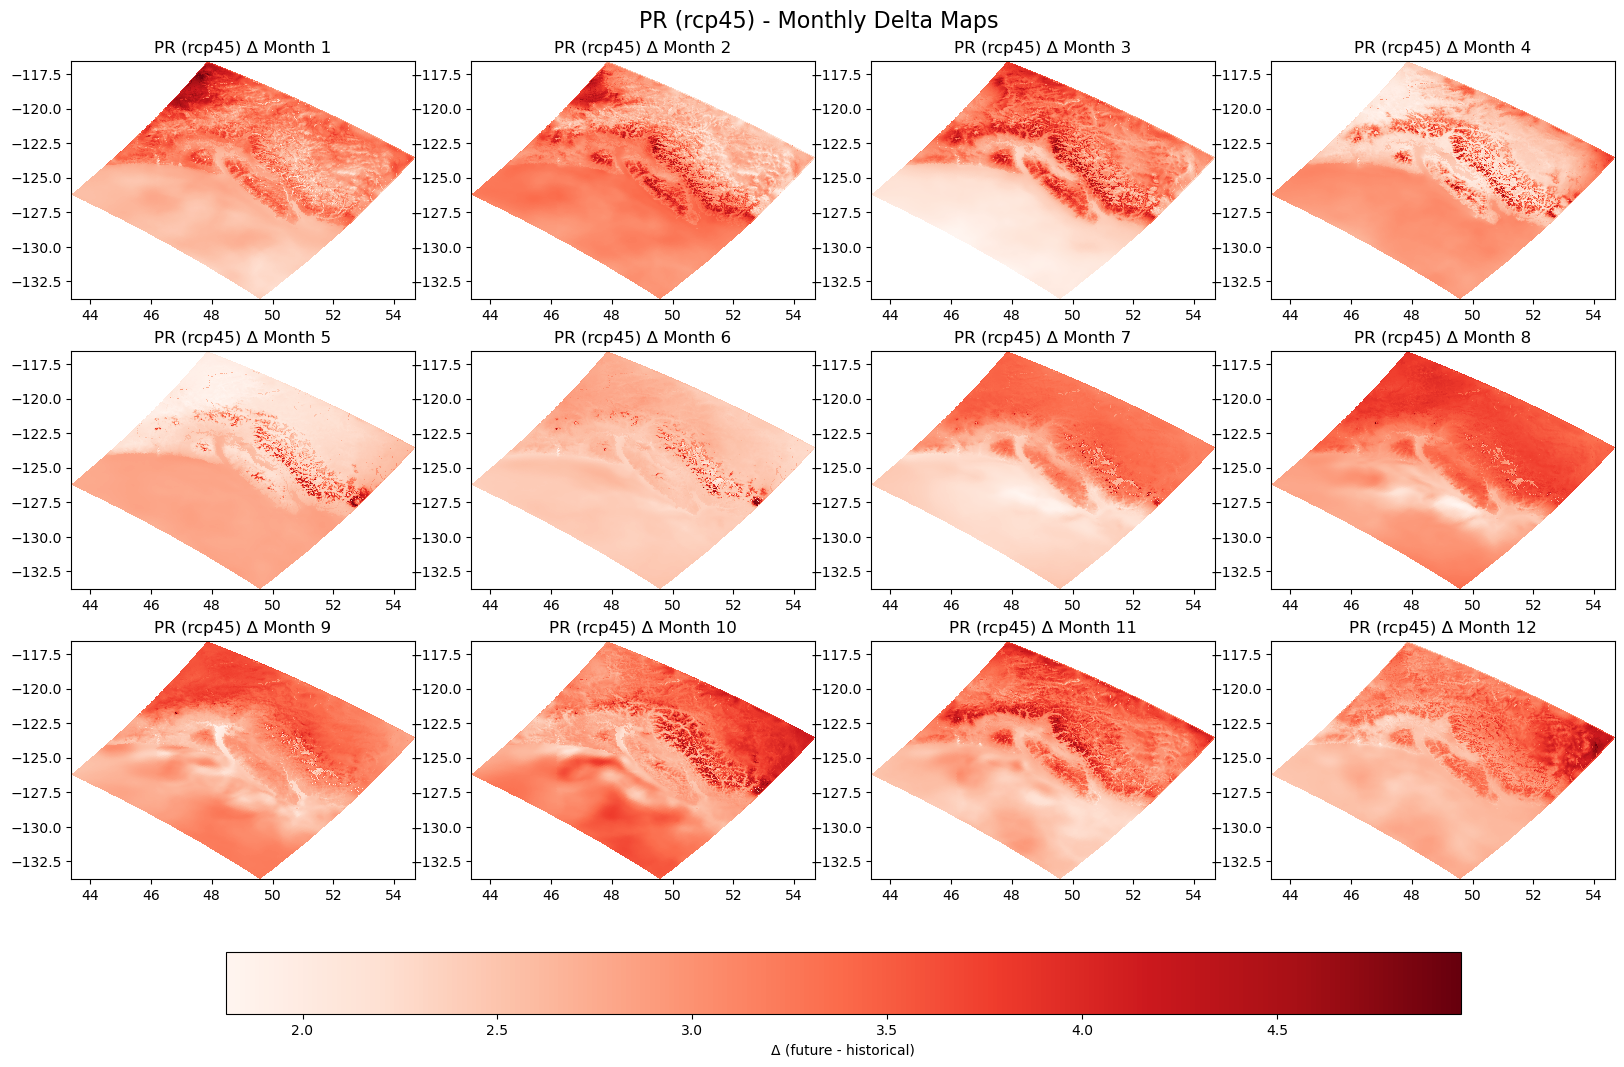

In [11]:
import matplotlib.pyplot as plt

def plot_monthly_deltas(delta, title_prefix="", cmap='Reds', vmin=None, vmax=None):
    """Plot monthly maps of the delta variable."""
    months = delta['month'].values
    n_months = len(months)

    ncols = 4
    nrows = int(np.ceil(n_months / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows),
                             constrained_layout=True, subplot_kw={'projection': None})

    for i, month in enumerate(months):
        ax = axes.flat[i]
        data = delta.sel(month=month)

        im = data.plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
        ax.set_title(f"{title_prefix} Δ Month {month}")
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Add one colorbar for all subplots
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.8)
    cbar.set_label('Δ (future - historical)')

    plt.suptitle(f"{title_prefix} - Monthly Delta Maps", fontsize=16)
    plt.show()

# Example usage:
plot_monthly_deltas(delta, title_prefix=f"{variable.upper()} ({period})", cmap='Reds')


In [12]:
def plot_monthly_deltas(delta, land_mask, ocean_mask, title_prefix="", cmap='Reds', vmin=None, vmax=None):
    """Plot monthly maps of the delta variable with land/ocean average checks."""
    months = delta['month'].values
    n_months = len(months)

    ncols = 4
    nrows = int(np.ceil(n_months / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows),
                             constrained_layout=True, subplot_kw={'projection': None})

    for i, month in enumerate(months):
        ax = axes.flat[i]
        data = delta.sel(month=month)

        # Compute land and ocean means
        land_avg = data.where(land_mask).mean(skipna=True).item()
        ocean_avg = data.where(ocean_mask).mean(skipna=True).item()

        # Print sanity check
        print(f"Month {month:2d} | Land avg: {land_avg:.3f} | Ocean avg: {ocean_avg:.3f}")

        # Plot
        im = data.plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
        ax.set_title(f"{title_prefix} Δ Month {month}\nLand: {land_avg:.2f}, Ocean: {ocean_avg:.2f}")
        ax.set_xlabel("")
        ax.set_ylabel("")
    
    # Shared colorbar
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.8)
    cbar.set_label('Δ (future - historical)')

    plt.suptitle(f"{title_prefix} - Monthly Delta Maps", fontsize=16)



Month  1 | Land avg: 3.596 | Ocean avg: 2.996
Month  2 | Land avg: 2.491 | Ocean avg: 2.590
Month  3 | Land avg: 4.025 | Ocean avg: 2.903
Month  4 | Land avg: 2.442 | Ocean avg: 2.757
Month  5 | Land avg: 1.652 | Ocean avg: 2.282
Month  6 | Land avg: 2.701 | Ocean avg: 2.440
Month  7 | Land avg: 3.886 | Ocean avg: 2.103
Month  8 | Land avg: 3.513 | Ocean avg: 2.452
Month  9 | Land avg: 3.520 | Ocean avg: 3.062
Month 10 | Land avg: 2.901 | Ocean avg: 2.808
Month 11 | Land avg: 3.286 | Ocean avg: 2.769
Month 12 | Land avg: 3.182 | Ocean avg: 2.609


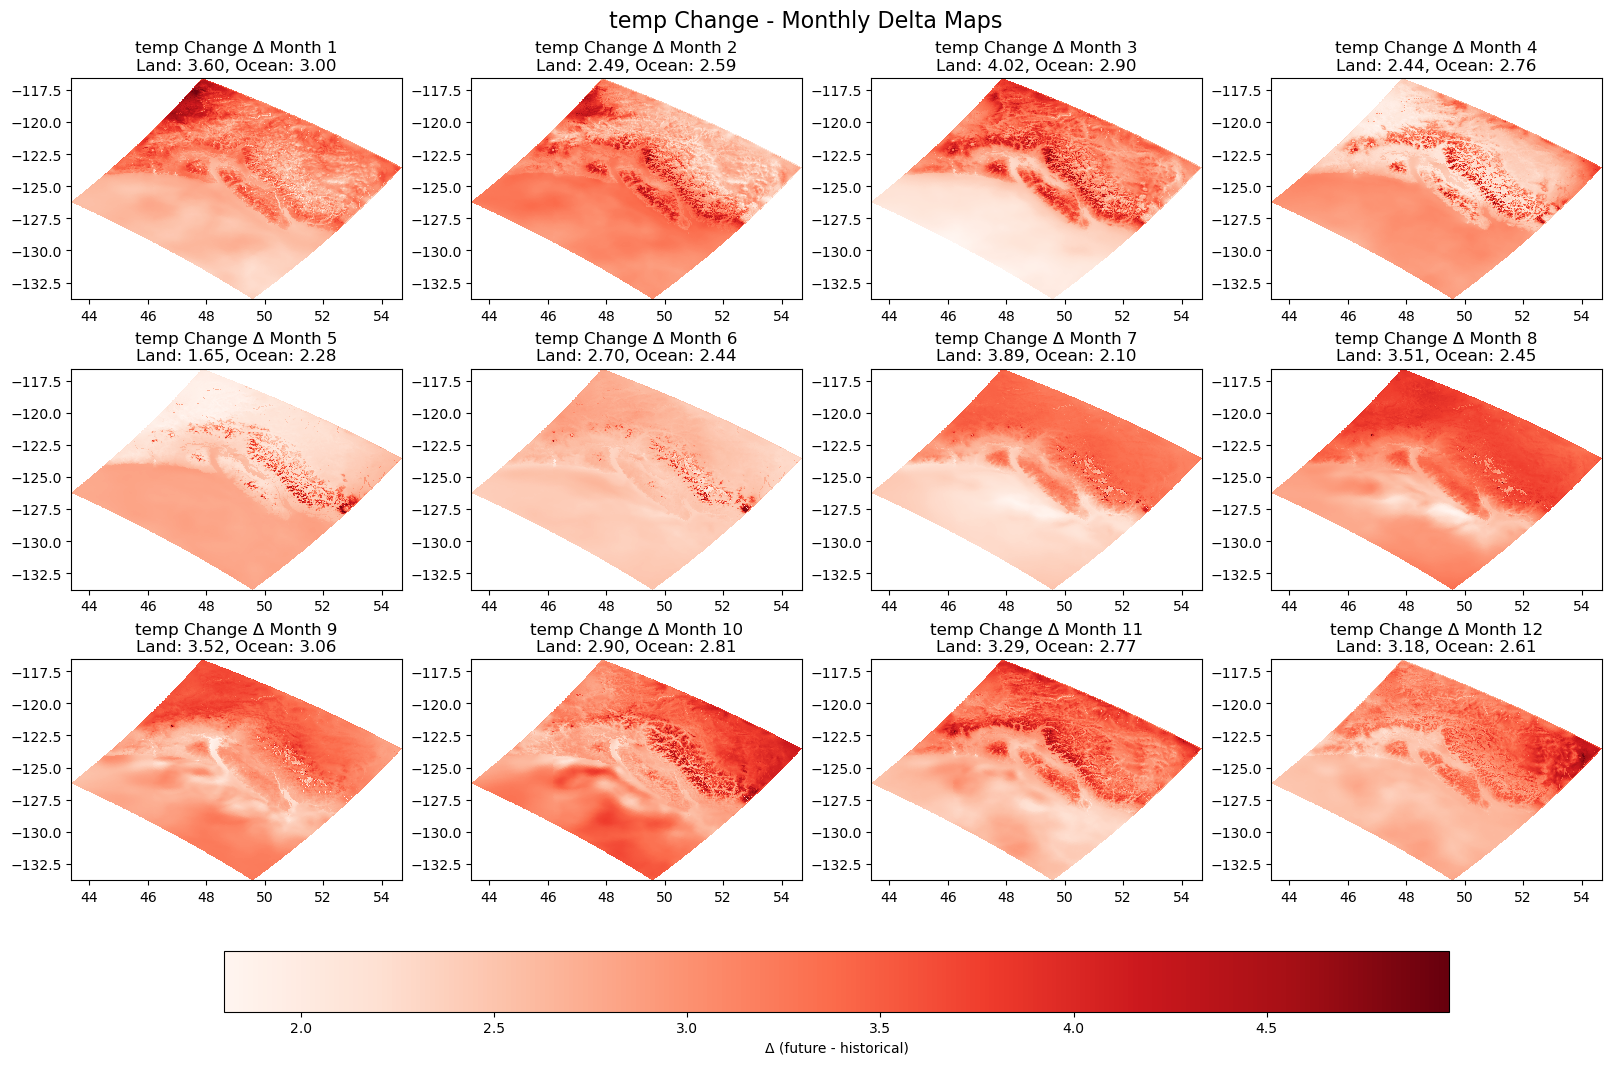

In [13]:

# delta should have .month as a dimension
plot_monthly_deltas(delta, land_mask, ocean_mask, title_prefix="temp Change", cmap="Reds")
plt.savefig('Regional_averages_map.png', format='png', bbox_inches='tight',transparent=False,dpi=500)


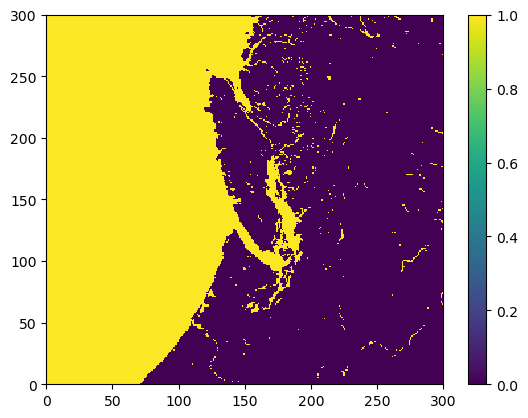

In [14]:
plt.pcolormesh(ocean_mask)
plt.colorbar()

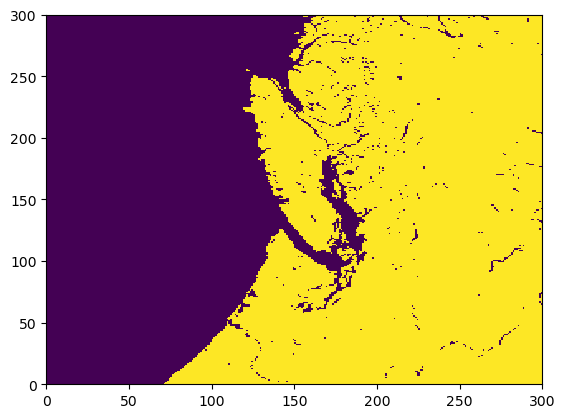

In [15]:
plt.pcolormesh(landmask)

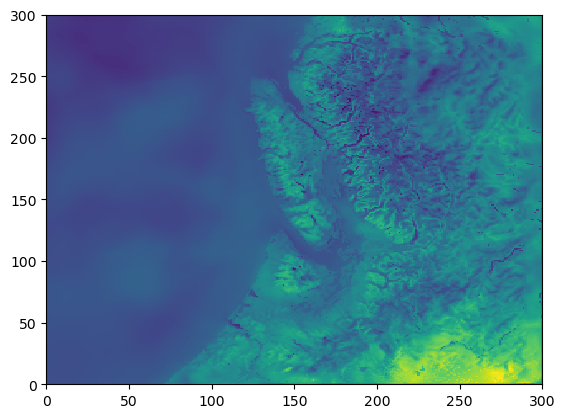

In [16]:
plt.pcolormesh(delta[0,:,:])

In [ ]:
land_avg = delta[0,:,:].where(landmask.data)

In [ ]:
plt.pcolormesh(land_avg[:,:])

In [ ]:
ocean_avg = delta[0,:,:].where(landmask.data==0)

In [ ]:
plt.pcolormesh(ocean_avg[:,:])

In [ ]:
print(np.nanmean(ocean_avg), np.nanmean(land_avg))

In [ ]:
# Ocean colors
color3 = '#364B9A'  # Ocean (historical) — deep blue
color2 = '#8CB6D0'  # Ocean (RCP8.5) — light muted blue

# Land colors
color4 = '#D55E00'  # Land (historical) — warm reddish-orange
color1 = '#E69F00'  # Land (RCP8.5) — golden yellow

subpanel = ['(a)','(b)','(c)','d', 'e', 'f', 'g','h','i','j']
#subpanel = ['1','2','3', '4', '5','6']

at=0.01
bt=.95

months = np.arange(1, 13)
plt.figure(figsize=(8,7))
ax = plt.subplot(3, 1, 1)
#om, lm=getaverages('t', period, domain)

plt.plot(months, do, label='ocean', marker='o', color=color2, markerfacecolor='none')
plt.plot(months, dl, label='land', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)

plt.plot(months, do_85, label='ocean', marker='o', color=color3, markerfacecolor='none')
plt.plot(months, dl_85, label='land RCP 8.5', linestyle='--', marker='d', color=color4,  markeredgecolor=color4)
ax.text(at, bt, subpanel[0], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)
plt.xticks(months)
plt.axis('tight')
plt.ylim([0,5])
ax.set_xticklabels([])
ax = plt.subplot(3, 1, 3)
#om, lm=getaverages('t', period, domain)

plt.plot(months, do_w, label='Ocean', marker='o', color=color2, markerfacecolor='none')
plt.plot(months, dl_w, label='Land', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)

plt.plot(months, do_w_85, label='Ocean RCP8.5', marker='o', color=color3, markerfacecolor='none')
plt.plot(months, dl_w_85, label='Land RCP 8.5', linestyle='--', marker='d', color=color4,  markeredgecolor=color4)
plt.plot(months, np.zeros(12), '-k')
ax.text(at, bt, subpanel[1], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
plt.ylim([-15,15])
plt.grid(True)
plt.xticks(months)
plt.ylabel(r' $\Delta_r$ Speed (%)')
plt.xlabel('Time (months)')
#plt.axis('tight')
#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
ax = plt.subplot(3, 1, 2)
#om, lm=getaverages('t', period, domain)

plt.plot(months, do_pr, label='Ocean RCP 4.5', marker='o', color=color2, markerfacecolor='none')
plt.plot(months, dl_pr, label='Land RCP 4.5', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)

plt.plot(months, do_pr_85, label='Ocean RCP 8.5', marker='o', color=color3, markerfacecolor='none')
plt.plot(months, dl_pr_85, label='Land RCP 8.5', linestyle='--', marker='d', color=color4,  markeredgecolor=color4)
plt.plot(months, np.zeros(12), '-k')

plt.ylabel(r'$\Delta_r$ precip (%)')
ax.set_xticklabels([])

#plt.ylabel(f'Mean fractional change in {var}')
#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
plt.xticks(months)
ax.text(at, bt, subpanel[2], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
plt.ylim([-55,55])
plt.grid(True)
plt.legend()
#plt.axis('tight')
plt.tight_layout()
plt.savefig('Regional_averages_relative.png', format='png', bbox_inches='tight',transparent=False,dpi=500)
